GROUP 2
Course: Python for Data Analysis
Members:
Jonel Oliquino	NF1034604
Mihir Mistry	NF1029056
Rincy Cherian	NF1020205
William Jorge de Oliveira Junior	NF1029305


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [3]:
properties = pd.read_csv("properties.csv")
meters = pd.read_csv("meters.csv")
meter_entries = pd.read_csv("meter_entries.csv")
uses = pd.read_csv("uses.csv")

properties.head(), meters.head(), meter_entries.head(), uses.head()


(               Property Name  Portfolio Manager ID         Street Address  \
 0  #11 Police Division - OLD              34999087          209 MAVETY ST   
 1  #14 Police Division - OLD              34999088        150 HARRISON ST   
 2      175 Memorial Park Ave              34999089  175 MEMORIAL PARK AVE   
 3                18 Dyas Rd.              34999090             18 DYAS RD   
 4       2 Civic Centre Court              34999091     2 CIVIC CENTRE CRT   
 
   City/Municipality Postal Code Property Type - Self-Selected  \
 0           Toronto     M6P 2M1                        Office   
 1           Toronto     M6J 2A4                        Office   
 2           Toronto     M4J 2K5                        Office   
 3        North York     M3B 1V5                        Office   
 4         Etobicoke     M9C 5A3                        Office   
 
    Gross Floor Area  Occupancy (%)  
 0             21119            100  
 1             24197            100  
 2              63

In [4]:
for df in [properties, meters, meter_entries, uses]:
    df.replace("Not Available", np.nan, inplace=True)


properties["Gross Floor Area"] = pd.to_numeric(properties["Gross Floor Area"], errors="coerce")
properties["Occupancy (%)"] = pd.to_numeric(properties["Occupancy (%)"], errors="coerce")

meter_entries["Usage/Quantity"] = pd.to_numeric(meter_entries["Usage/Quantity"], errors="coerce")
meter_entries["Cost ($)"] = pd.to_numeric(meter_entries["Cost ($)"], errors="coerce")

print("Duplicate rows in meter_entries before:", meter_entries.duplicated().sum())
meter_entries = meter_entries.drop_duplicates()
print("Duplicate rows in meter_entries after:", meter_entries.duplicated().sum())

Duplicate rows in meter_entries before: 0
Duplicate rows in meter_entries after: 0


In [5]:
print("properties:", properties.shape)
print("meters:", meters.shape)
print("meter_entries:", meter_entries.shape)
print("uses:", uses.shape)


properties: (1760, 8)
meters: (2585, 8)
meter_entries: (26222, 11)
uses: (1760, 7)


## 1. Data Preparation – Filter to Electric Grid Meters in kWh


In [7]:
print(meter_entries["Meter Type"].unique())
print(meter_entries["Usage Units"].unique())


['Electric - Grid' 'Natural Gas' 'Average Influent Flow' 'District Steam'
 'District Chilled Water - Other']
['kWh (thousand Watt-hours)' 'cm (cubic meters)' 'Cubic Meters per Day'
 'kLbs. (thousand pounds)' 'ton hours']


In [8]:
elec = meter_entries[
    (meter_entries["Meter Type"] == "Electric - Grid") &
    (meter_entries["Usage Units"].str.contains("kWh"))
].copy()

print(elec.shape)
elec["Usage Units"].value_counts()



(18109, 11)


Usage Units
kWh (thousand Watt-hours)    18109
Name: count, dtype: int64

In [9]:
if "usage_kwh" not in elec.columns:
    if "Usage/Quantity" in elec.columns:
        elec = elec.rename(columns={"Usage/Quantity": "usage_kwh"})
        print("Renamed 'Usage/Quantity' to 'usage_kwh' in elec")
    else:
        raise ValueError("Neither 'usage_kwh' nor 'Usage/Quantity' found in elec")

before_elec = len(elec)
elec = elec[elec["usage_kwh"] > 0].copy()
print("Removed", before_elec - len(elec), "rows with non-positive usage_kwh")

before_props = len(properties)
properties = properties[properties["Gross Floor Area"] > 0].copy()
print("Removed", before_props - len(properties), "rows with non-positive Gross Floor Area")


Renamed 'Usage/Quantity' to 'usage_kwh' in elec
Removed 389 rows with non-positive usage_kwh
Removed 0 rows with non-positive Gross Floor Area


In [10]:
elec = elec.rename(columns={"Usage/Quantity": "usage_kwh"})
elec[["Portfolio Manager ID", "Start Date", "End Date", "usage_kwh"]].head()


,Portfolio Manager ID,Start Date,End Date,usage_kwh
0,35000258,2022-01-01 00:00:00,2022-02-01 00:00:00,42876.27
1,35000258,2022-02-01 00:00:00,2022-03-01 00:00:00,39721.72
2,35000258,2022-03-01 00:00:00,2022-04-01 00:00:00,41278.04
3,35000258,2022-04-01 00:00:00,2022-05-01 00:00:00,37111.95
4,35000258,2022-05-01 00:00:00,2022-06-01 00:00:00,41778.27


In [11]:
elec_props = elec.merge(
    properties,
    on="Portfolio Manager ID",
    how="left",
    suffixes=("", "_prop")
)
elec_props.head()


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,usage_kwh,Usage Units,Cost ($),Property Name_prop,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01 00:00:00,2022-02-01 00:00:00,42876.27,kWh (thousand Watt-hours),5775.70,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01 00:00:00,2022-03-01 00:00:00,39721.72,kWh (thousand Watt-hours),5377.67,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01 00:00:00,2022-04-01 00:00:00,41278.04,kWh (thousand Watt-hours),5611.00,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01 00:00:00,2022-05-01 00:00:00,37111.95,kWh (thousand Watt-hours),4989.06,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01 00:00:00,2022-06-01 00:00:00,41778.27,kWh (thousand Watt-hours),5984.66,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100


In [12]:
uses_agg = uses.groupby("Portfolio Manager ID").agg(
    n_uses=("Use Type", "nunique"),
    total_use_area=("Gross Floor Area for Use", "sum")
).reset_index()

data = elec_props.merge(
    uses_agg,
    on="Portfolio Manager ID",
    how="left"
)
data.head()


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,usage_kwh,Usage Units,Cost ($),Property Name_prop,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%),n_uses,total_use_area
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01 00:00:00,2022-02-01 00:00:00,42876.27,kWh (thousand Watt-hours),5775.70,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100,1,20344.0
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01 00:00:00,2022-03-01 00:00:00,39721.72,kWh (thousand Watt-hours),5377.67,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100,1,20344.0
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01 00:00:00,2022-04-01 00:00:00,41278.04,kWh (thousand Watt-hours),5611.00,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100,1,20344.0
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01 00:00:00,2022-05-01 00:00:00,37111.95,kWh (thousand Watt-hours),4989.06,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100,1,20344.0
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01 00:00:00,2022-06-01 00:00:00,41778.27,kWh (thousand Watt-hours),5984.66,#13 Police Division,1435 EGLINTON AVE W,Toronto,M6C 3Z4,Police Station,20344,100,1,20344.0


In [13]:
data = data.dropna(subset=["usage_kwh"])
data.shape


(17720, 20)

In [14]:
data["Start Date"] = pd.to_datetime(data["Start Date"])
data["End Date"] = pd.to_datetime(data["End Date"])

data["year"] = data["Start Date"].dt.year
data["month"] = data["Start Date"].dt.month

data["days_in_period"] = (data["End Date"] - data["Start Date"]).dt.days

data["season"] = pd.cut(
    data["month"],
    bins=[0, 3, 6, 9, 12],
    labels=["Winter", "Spring", "Summer", "Fall"]
)


In [15]:
selected_cols = [
    "usage_kwh",
    "Gross Floor Area",
    "Occupancy (%)",
    "n_uses",
    "total_use_area",
    "year",
    "month",
    "days_in_period",
    "season",
    "Property Type - Self-Selected"
]

model_data = data[selected_cols].copy()
model_data.shape

numeric_cols = ["Gross Floor Area", "Occupancy (%)", "n_uses",
                "total_use_area", "year", "month", "days_in_period"]
cat_cols = ["Property Type - Self-Selected", "season"]

for col in numeric_cols:
    model_data[col] = model_data[col].fillna(model_data[col].median())

for col in cat_cols:
    model_data[col] = model_data[col].astype("object").fillna("Unknown")


In [16]:
numeric_cols = ["Gross Floor Area", "Occupancy (%)", "n_uses", "total_use_area", "year", "month"]
cat_cols = ["Property Type - Self-Selected"]

for col in numeric_cols:
    model_data[col] = model_data[col].fillna(model_data[col].median())

for col in cat_cols:
    model_data[col] = model_data[col].fillna("Unknown")


In [17]:

gfa_cap = model_data["Gross Floor Area"].quantile(0.99)

model_data["Gross Floor Area"] = np.where(
    model_data["Gross Floor Area"] > gfa_cap,
    gfa_cap,
    model_data["Gross Floor Area"]
)

print("99th percentile cap for GFA:", gfa_cap)



99th percentile cap for GFA: 302735.0


In [18]:
model_data["log_usage_kwh"] = np.log1p(model_data["usage_kwh"])


In [19]:
model_data[["usage_kwh", "log_usage_kwh"]].head()


,usage_kwh,log_usage_kwh
0,42876.27,10.666097
1,39721.72,10.589679
2,41278.04,10.628110
3,37111.95,10.521721
4,41778.27,10.640156


In [20]:
model_data.describe()

,usage_kwh,Gross Floor Area,Occupancy (%),n_uses,total_use_area,year,month,days_in_period,log_usage_kwh
count,1.772000e+04,17720.000000,17720.000000,17720.0,17720.000000,17720.0,17720.000000,17720.000000,17720.000000
mean,7.764462e+04,15620.559481,93.922122,1.0,14883.189052,2022.0,6.006433,30.340801,8.337793
std,4.126198e+05,43021.284127,23.893083,0.0,58821.803901,0.0,3.157431,1.146400,2.581469
min,1.000000e-02,1.000000,0.000000,1.0,0.000000,2022.0,1.000000,1.000000,0.009950
25%,6.150475e+02,1.000000,100.000000,1.0,0.000000,2022.0,3.000000,30.000000,6.423324
50%,4.630765e+03,329.000000,100.000000,1.0,156.000000,2022.0,6.000000,31.000000,8.440693
75%,2.530980e+04,11765.000000,100.000000,1.0,7664.000000,2022.0,9.000000,31.000000,10.138986
max,1.199675e+07,302735.000000,100.000000,1.0,986748.000000,2022.0,11.000000,31.000000,16.300147


In [21]:
model_data["Gross Floor Area"].describe()


count     17720.000000
mean      15620.559481
std       43021.284127
min           1.000000
25%           1.000000
50%         329.000000
75%       11765.000000
max      302735.000000
Name: Gross Floor Area, dtype: float64

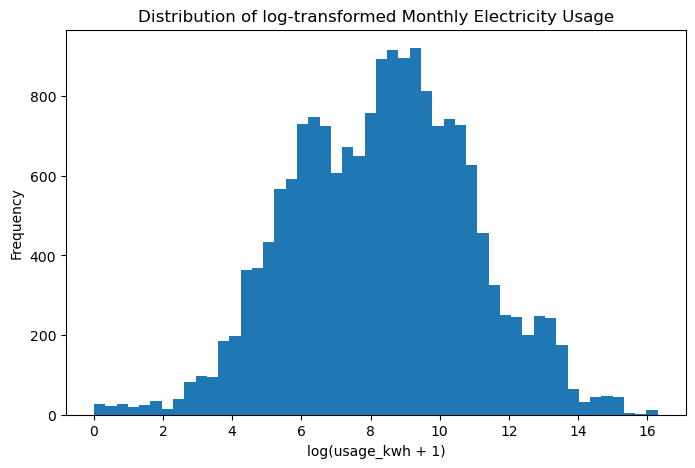

In [22]:
plt.figure(figsize=(8,5))
plt.hist(model_data["log_usage_kwh"], bins=50)
plt.xlabel("log(usage_kwh + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of log-transformed Monthly Electricity Usage")
plt.show()



In [23]:
model_data.describe()


,usage_kwh,Gross Floor Area,Occupancy (%),n_uses,total_use_area,year,month,days_in_period,log_usage_kwh
count,1.772000e+04,17720.000000,17720.000000,17720.0,17720.000000,17720.0,17720.000000,17720.000000,17720.000000
mean,7.764462e+04,15620.559481,93.922122,1.0,14883.189052,2022.0,6.006433,30.340801,8.337793
std,4.126198e+05,43021.284127,23.893083,0.0,58821.803901,0.0,3.157431,1.146400,2.581469
min,1.000000e-02,1.000000,0.000000,1.0,0.000000,2022.0,1.000000,1.000000,0.009950
25%,6.150475e+02,1.000000,100.000000,1.0,0.000000,2022.0,3.000000,30.000000,6.423324
50%,4.630765e+03,329.000000,100.000000,1.0,156.000000,2022.0,6.000000,31.000000,8.440693
75%,2.530980e+04,11765.000000,100.000000,1.0,7664.000000,2022.0,9.000000,31.000000,10.138986
max,1.199675e+07,302735.000000,100.000000,1.0,986748.000000,2022.0,11.000000,31.000000,16.300147


In [24]:
model_data["kwh_per_sqft"] = model_data["usage_kwh"] / model_data["Gross Floor Area"]
model_data["kwh_per_sqft"].describe()

count    1.772000e+04
mean     2.894152e+04
std      1.812472e+05
min      2.351731e-05
25%      9.566754e-01
50%      3.551444e+00
75%      1.904681e+02
max      4.034644e+06
Name: kwh_per_sqft, dtype: float64

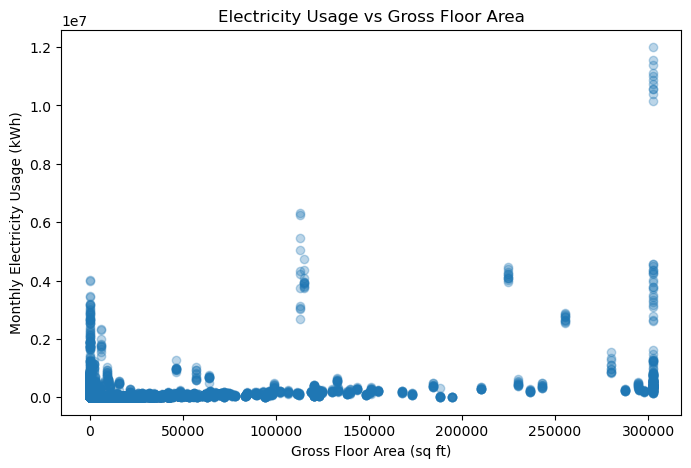

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(model_data["Gross Floor Area"], model_data["usage_kwh"], alpha=0.3)
plt.xlabel("Gross Floor Area (sq ft)")
plt.ylabel("Monthly Electricity Usage (kWh)")
plt.title("Electricity Usage vs Gross Floor Area")
plt.show()


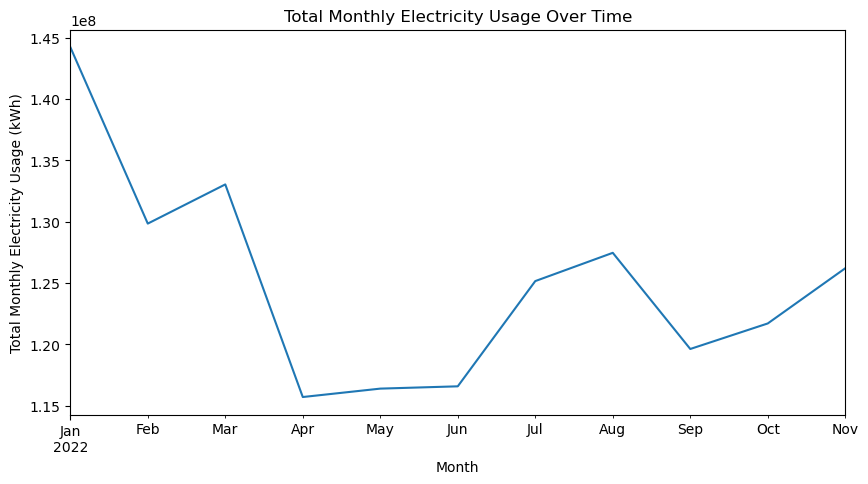

In [26]:
# Total monthly usage over time
data["month_period"] = data["Start Date"].dt.to_period("M")
monthly_usage = data.groupby("month_period")["usage_kwh"].sum()

plt.figure(figsize=(10, 5))
monthly_usage.plot()
plt.xlabel("Month")
plt.ylabel("Total Monthly Electricity Usage (kWh)")
plt.title("Total Monthly Electricity Usage Over Time")
plt.show()


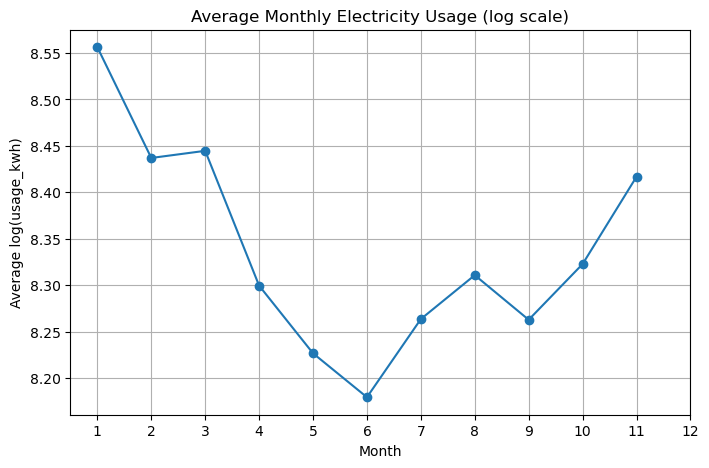

In [27]:

monthly_trend = model_data.groupby("month")["log_usage_kwh"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(monthly_trend["month"], monthly_trend["log_usage_kwh"], marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average log(usage_kwh)")
plt.title("Average Monthly Electricity Usage (log scale)")
plt.grid(True)
plt.show()


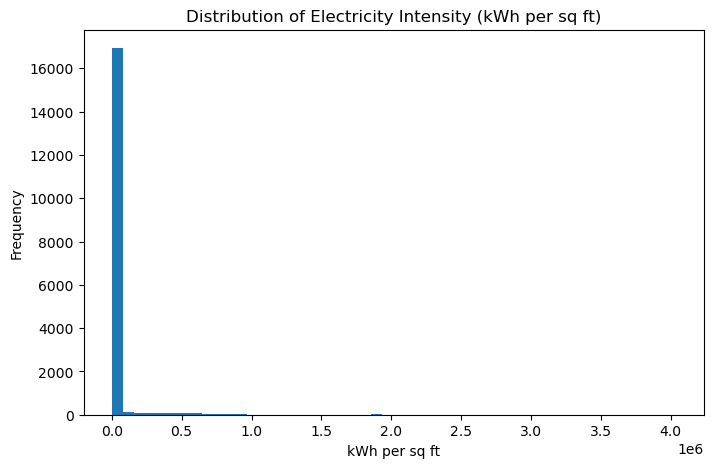

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(model_data["kwh_per_sqft"].dropna(), bins=50)
plt.xlabel("kWh per sq ft")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Intensity (kWh per sq ft)")
plt.show()


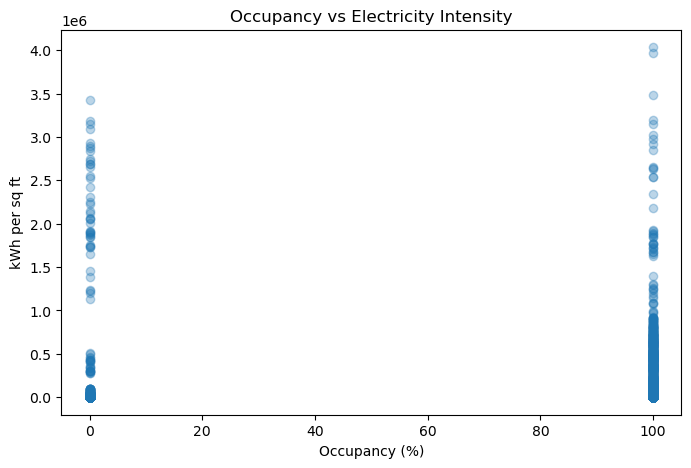

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(model_data["Occupancy (%)"], model_data["kwh_per_sqft"], alpha=0.3)
plt.xlabel("Occupancy (%)")
plt.ylabel("kWh per sq ft")
plt.title("Occupancy vs Electricity Intensity")
plt.show()


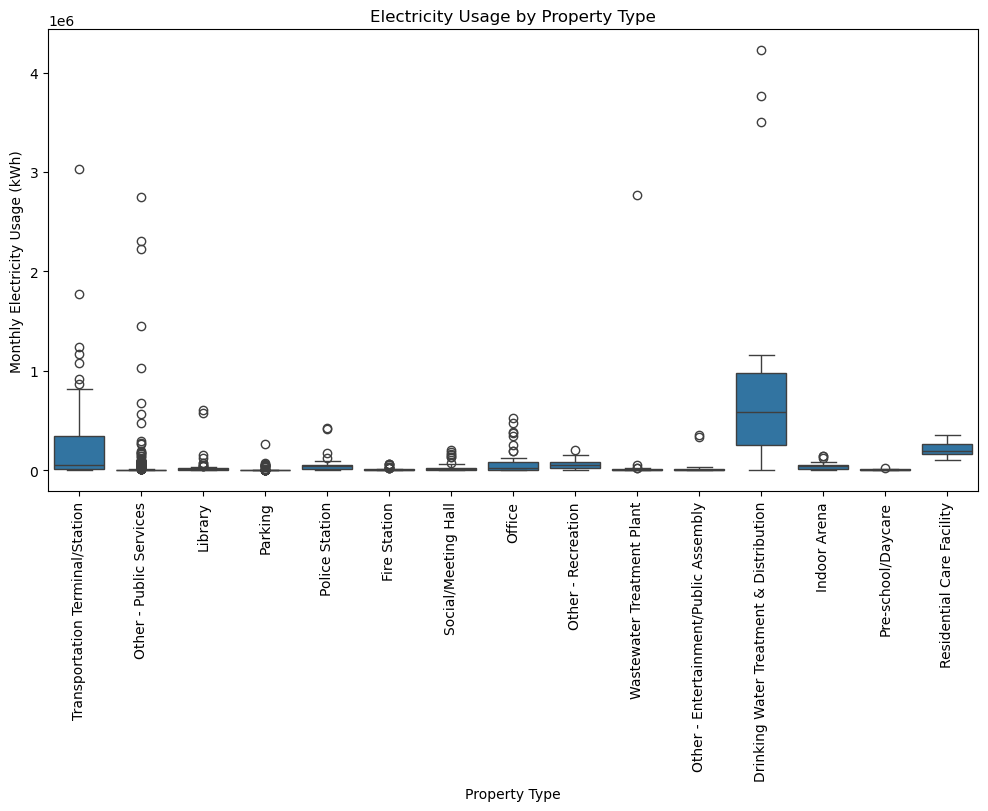

In [30]:
plt.figure(figsize=(12, 6))
sample = model_data.sample(min(2000, len(model_data)))   # avoids huge plot

sns.boxplot(
    data=sample,
    x="Property Type - Self-Selected",
    y="usage_kwh"
)

plt.xticks(rotation=90)
plt.title("Electricity Usage by Property Type")
plt.ylabel("Monthly Electricity Usage (kWh)")
plt.xlabel("Property Type")
plt.show()


merged2 shape: (17720, 18)


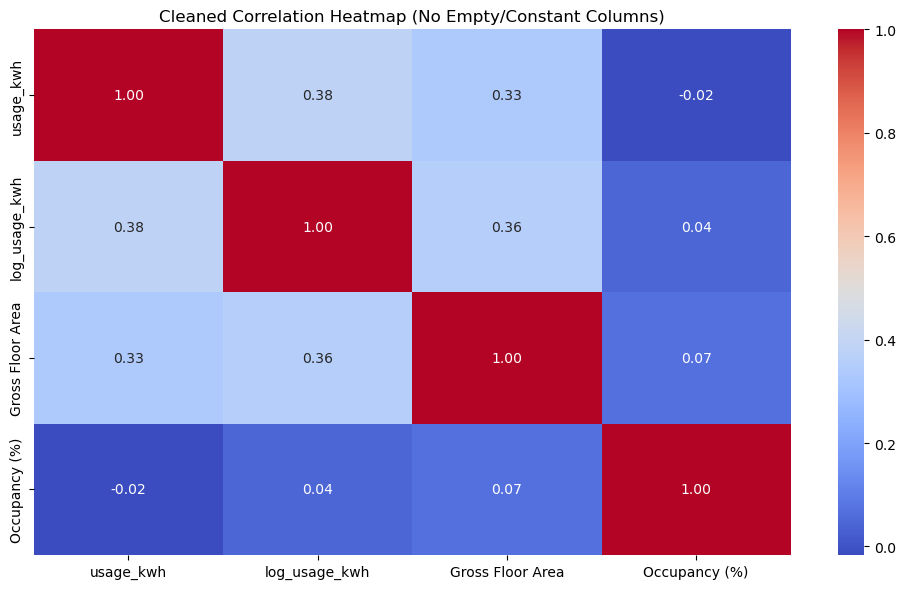

In [31]:

merged2 = elec.merge(properties, on="Portfolio Manager ID", how="left")

print("merged2 shape:", merged2.shape)
merged2.head()

if "usage_kwh" in merged2.columns and "log_usage_kwh" not in merged2.columns:
    merged2["log_usage_kwh"] = np.log1p(merged2["usage_kwh"])

numeric_cols = [
    "usage_kwh",
    "log_usage_kwh",
    "Gross Floor Area",
    "Occupancy (%)",
    "n_uses",
    "total_use_area",
    "year",
    "month"
]

for col in ["n_uses", "year", "month", "Gross Floor Area",
            "Occupancy (%)", "total_use_area", "usage_kwh", "log_usage_kwh"]:
    if col in merged2.columns:
        merged2[col] = pd.to_numeric(merged2[col], errors="coerce")

numeric_cols_existing = [c for c in numeric_cols if c in merged2.columns]

numeric_df = merged2[numeric_cols_existing].select_dtypes(include="number")
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]  # remove empty/constant cols

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cleaned Correlation Heatmap (No Empty/Constant Columns)")
plt.tight_layout()
plt.show()


In [32]:
model_data_encoded = pd.get_dummies(
    model_data,
    columns=["Property Type - Self-Selected", "season"],  # include season
    drop_first=True
)

model_data_encoded.head()


,usage_kwh,Gross Floor Area,Occupancy (%),n_uses,total_use_area,year,month,days_in_period,log_usage_kwh,kwh_per_sqft,...,Property Type - Self-Selected_Parking,Property Type - Self-Selected_Police Station,Property Type - Self-Selected_Pre-school/Daycare,Property Type - Self-Selected_Residential Care Facility,Property Type - Self-Selected_Social/Meeting Hall,Property Type - Self-Selected_Transportation Terminal/Station,Property Type - Self-Selected_Wastewater Treatment Plant,season_Spring,season_Summer,season_Winter
0,42876.27,20344.0,100,1,20344.0,2022,1,31,10.666097,2.107563,...,False,True,False,False,False,False,False,False,False,True
1,39721.72,20344.0,100,1,20344.0,2022,2,28,10.589679,1.952503,...,False,True,False,False,False,False,False,False,False,True
2,41278.04,20344.0,100,1,20344.0,2022,3,31,10.628110,2.029003,...,False,True,False,False,False,False,False,False,False,True
3,37111.95,20344.0,100,1,20344.0,2022,4,30,10.521721,1.824221,...,False,True,False,False,False,False,False,True,False,False
4,41778.27,20344.0,100,1,20344.0,2022,5,31,10.640156,2.053592,...,False,True,False,False,False,False,False,True,False,False


In [33]:
if "log_usage_kwh" in model_data_encoded.columns:
    
    y = model_data_encoded["log_usage_kwh"]
elif "usage_kwh" in model_data_encoded.columns:
   
    y = np.log1p(model_data_encoded["usage_kwh"])
else:
    raise ValueError("Cannot find usage_kwh or log_usage_kwh in model_data_encoded")


cols_to_drop = []
for col in ["usage_kwh", "log_usage_kwh", "kwh_per_sqft"]:
    if col in model_data_encoded.columns:
        cols_to_drop.append(col)

X = model_data_encoded.drop(cols_to_drop, axis=1)

X.shape, y.shape


((17720, 24), (17720,))

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [35]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("DummyRegressor – Test MAE:", mean_absolute_error(y_test, y_pred_dummy))
print("DummyRegressor – Test RMSE:", mean_squared_error(y_test, y_pred_dummy, squared=False))
print("DummyRegressor – Test R²:", r2_score(y_test, y_pred_dummy))


DummyRegressor – Test MAE: 2.06762192251406
DummyRegressor – Test RMSE: 2.5631825866468345
DummyRegressor – Test R²: -0.00018836372212649444


C:\Users\maith\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [36]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)


In [37]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
from sklearn.metrics import root_mean_squared_error

rmse_lin = root_mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression:")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R²:", r2_lin)


Linear Regression:
MAE: 1.4718019036464318
RMSE: 1.9652927645009617
R²: 0.4120001434069912


In [38]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = mean_squared_error(y_test, y_pred_lasso, squared=False)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression:")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)


Lasso Regression:
MAE: 1.477760729689116
RMSE: 1.9693259378341708
R²: 0.4095842807062632


C:\Users\maith\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [39]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [40]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)


Random Forest:
MAE: 0.7690349246842829
RMSE: 1.3992637072112302
R²: 0.7019275415425755


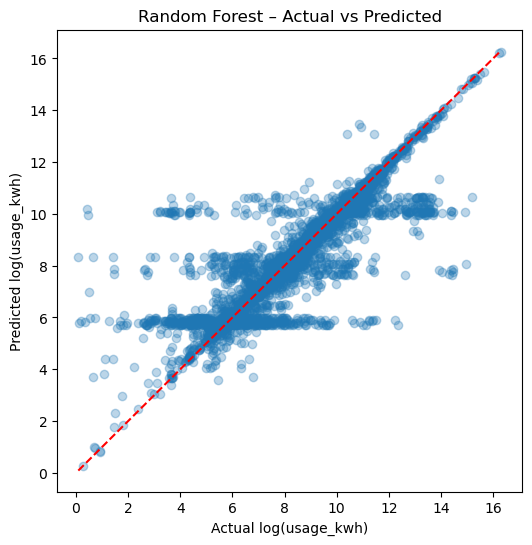

In [41]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual log(usage_kwh)")
plt.ylabel("Predicted log(usage_kwh)")
plt.title("Random Forest – Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split


In [43]:
y = model_data_encoded["log_usage_kwh"]
X = model_data_encoded.drop(columns=["log_usage_kwh"])


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_best = best_rf.predict(X_test)

print("Best params:", grid.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", mean_squared_error(y_test, y_pred_best, squared=False))  # still works
print("R²:", r2_score(y_test, y_pred_best))


In [ ]:
y_train_pred = best_rf.predict(X_train)

print("Random Forest - Train R²:", r2_score(y_train, y_train_pred))
print("Random Forest - Test R²:", r2_score(y_test, y_pred_best))


In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log(usage_kwh)")
plt.ylabel("Residuals")
plt.title("Residual Plot – Random Forest (Test Set)")
plt.show()


In [ ]:
# Feature importance for the best Random Forest model
importances = best_rf.feature_importances_
feature_names = X.columns  # after encoding

# Sort by importance
idx = np.argsort(importances)[::-1][:15]  # top 15 features
plt.figure(figsize=(8, 6))
plt.barh(range(len(idx)), importances[idx][::-1])
plt.yticks(range(len(idx)), feature_names[idx][::-1])
plt.xlabel("Feature Importance (Random Forest)")
plt.title("Top 15 Most Important Features")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals – Random Forest (Test Set)")
plt.show()
